# Домашнее задание: Eigenfaces - Распознавание лиц с помощью PCA

В этом задании вы реализуете метод **Eigenfaces** для распознавания лиц с использованием **метода главных компонент (PCA)**.

Мы будем использовать датасет LFW (Labeled Faces in the Wild) из scikit-learn.

## 1. Загрузка данных

Датасет LFW содержит изображения лиц известных людей. Каждое изображение — это полутоновое изображение, которое можно представить как вектор.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# Загружаем датасет (только люди с минимум 70 изображениями)
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Получаем данные
X = lfw_people.data  # Каждая строка — это развёрнутое изображение
n_samples, n_features = X.shape
h, w = lfw_people.images.shape[1:3]  # Размеры изображения

print(f"Датасет: {n_samples} изображений, каждое {h}x{w} = {n_features} пикселей")

Датасет: 1288 изображений, каждое 50x37 = 1850 пикселей


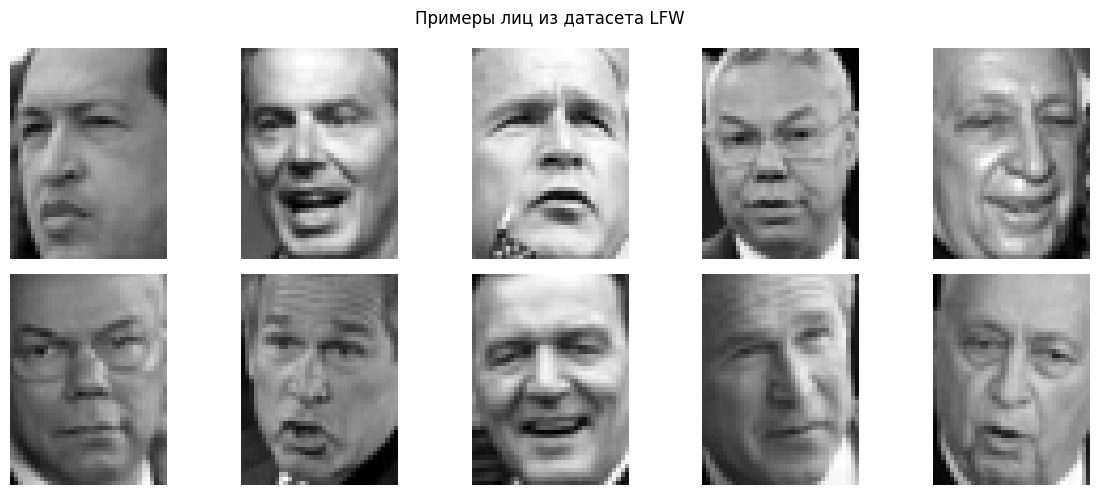

In [2]:
# Отображаем несколько примеров лиц
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(h, w), cmap='gray')
    ax.axis('off')
plt.suptitle('Примеры лиц из датасета LFW')
plt.tight_layout()
plt.show()

## 2. Теория PCA

### Идея

Каждое изображение лица — это точка в многомерном пространстве ($\mathbb{R}^{n}$, где $n$ = число пикселей). PCA находит подпространство меньшей размерности, которое захватывает наибольшую дисперсию данных.

### Математическая формулировка

Дана матрица данных $\mathbf{X} \in \mathbb{R}^{m \times n}$ (m образцов, n признаков):

1. **Центрирование данных**: $\bar{\mathbf{X}} = \mathbf{X} - \boldsymbol{\mu}$, где $\boldsymbol{\mu}$ — среднее лицо

2. **Вычисление ковариационной матрицы**: $\mathbf{C} = \frac{1}{m-1}\bar{\mathbf{X}}^T\bar{\mathbf{X}}$

3. **Собственное разложение**: $\mathbf{C}\mathbf{v}_i = \lambda_i\mathbf{v}_i$

Собственные векторы $\mathbf{v}_i$ (отсортированные по убыванию $\lambda_i$) — это **главные компоненты**.

При применении к лицам эти собственные векторы называются **eigenfaces** (собственные лица).

## 3. Реализация PCA с помощью NumPy

Мы реализуем PCA с нуля, используя SVD-разложение:

$$\bar{\mathbf{X}} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^T$$

Столбцы матрицы $\mathbf{V}$ — это главные компоненты (eigenfaces).

### Задание 1: Вычисление среднего лица

Вычислите среднее лицо и центрируйте данные.

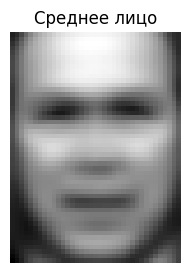

In [3]:
# TODO: Вычислите среднее лицо (среднее по всем изображениям, axis=0)
mean_face = np.mean(X, axis=0)

# TODO: Центрируйте данные, вычтя среднее лицо из каждого изображения
X_centered = X - mean_face

# Отображаем среднее лицо
plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(h, w), cmap='gray')
plt.title('Среднее лицо')
plt.axis('off')
plt.show()

### Задание 2: Вычисление SVD

Вычислите SVD-разложение центрированных данных.

In [4]:
# TODO: Вычислите SVD-разложение центрированных данных
# Используйте np.linalg.svd с параметром full_matrices=False
# X_centered = U @ Sigma @ Vt
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Строки Vt — это главные компоненты (eigenfaces)
eigenfaces = Vt

print(f"Форма eigenfaces: {eigenfaces.shape}")
print(f"Количество компонент: {len(S)}")

Форма eigenfaces: (1288, 1850)
Количество компонент: 1288


## 4. Визуализация Eigenfaces

Первые eigenfaces захватывают наиболее значимые вариации в датасете.

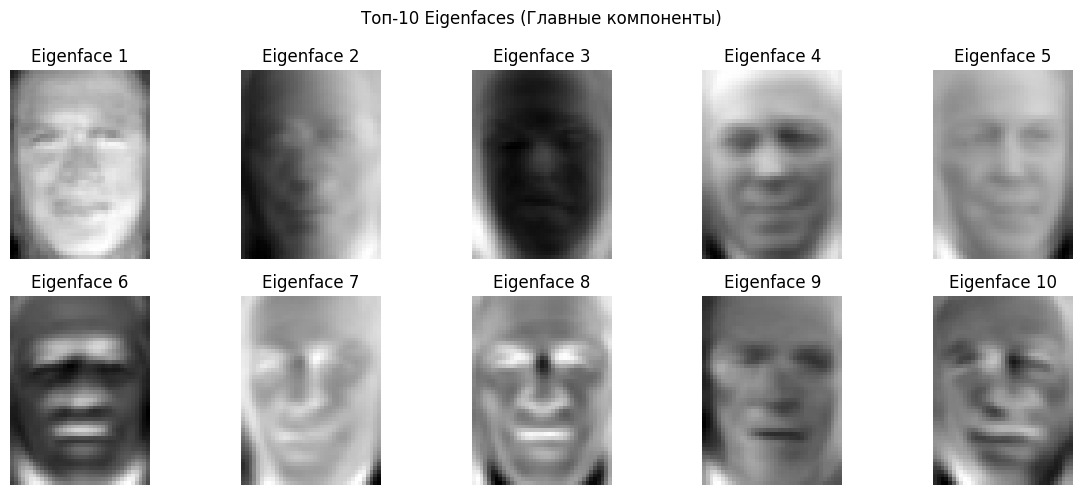

In [5]:
# Отображаем первые 10 eigenfaces
n_eigenfaces = 10
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(h, w), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.suptitle('Топ-10 Eigenfaces (Главные компоненты)')
plt.tight_layout()
plt.show()

## 5. Объяснённая дисперсия

Сингулярные числа показывают, сколько дисперсии объясняет каждая компонента:

$$\text{Доля объяснённой дисперсии}_i = \frac{\sigma_i^2}{\sum_j \sigma_j^2}$$

### Задание 3: Вычисление объяснённой дисперсии

Вычислите долю объяснённой дисперсии для каждой компоненты и накопленную дисперсию.

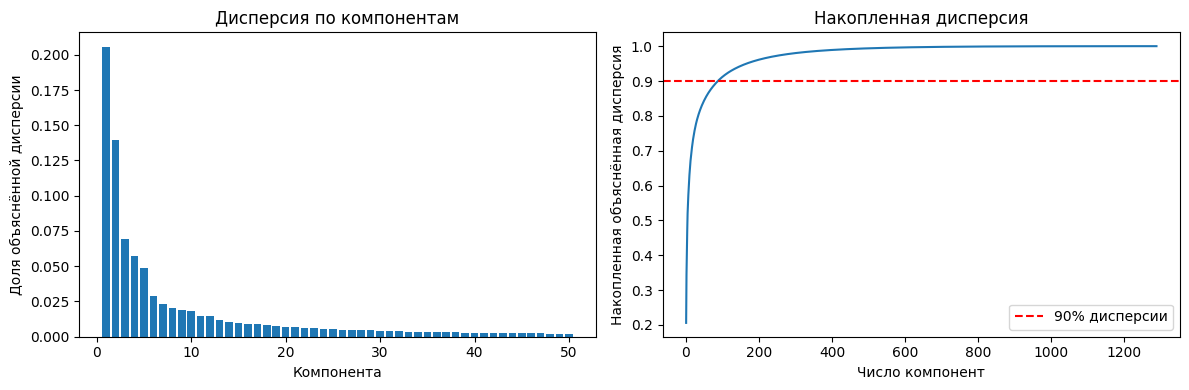

Компонент для 90% дисперсии: 88


In [6]:
# TODO: Вычислите долю объяснённой дисперсии для каждой компоненты
# Формула: sigma_i^2 / sum(sigma_j^2)
explained_variance = S**2 / np.sum(S**2)

# TODO: Вычислите накопленную (кумулятивную) дисперсию
# Используйте np.cumsum
cumulative_variance = np.cumsum(explained_variance)

# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, 51), explained_variance[:50])
ax1.set_xlabel('Компонента')
ax1.set_ylabel('Доля объяснённой дисперсии')
ax1.set_title('Дисперсия по компонентам')

ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
ax2.axhline(y=0.9, color='r', linestyle='--', label='90% дисперсии')
ax2.set_xlabel('Число компонент')
ax2.set_ylabel('Накопленная объяснённая дисперсия')
ax2.set_title('Накопленная дисперсия')
ax2.legend()

plt.tight_layout()
plt.show()

# Находим число компонент для 90% дисперсии
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Компонент для 90% дисперсии: {n_components_90}")

## 6. Реконструкция лица

Лицо можно реконструировать, используя $k$ главных компонент:

$$\mathbf{x}_{\text{reconstructed}} = \boldsymbol{\mu} + \sum_{i=1}^{k} \alpha_i \mathbf{v}_i$$

где $\alpha_i = (\mathbf{x} - \boldsymbol{\mu})^T \mathbf{v}_i$ — коэффициенты проекции.

### Задание 4: Реализация функции реконструкции лица

Реализуйте функцию для реконструкции лица с использованием заданного числа eigenfaces.

In [7]:
def reconstruct_face(face, mean_face, eigenfaces, n_components):
    """
    Реконструирует лицо, используя n_components eigenfaces.

    Параметры:
        face: исходное изображение лица (вектор)
        mean_face: среднее лицо
        eigenfaces: матрица eigenfaces (каждая строка — eigenface)
        n_components: число компонент для реконструкции

    Возвращает:
        reconstructed: реконструированное лицо
    """
    # TODO: Центрируйте лицо (вычтите среднее лицо)
    centered = face - mean_face

    # TODO: Спроецируйте центрированное лицо на первые n_components eigenfaces
    # coefficients = centered @ eigenfaces[:n_components].T
    coefficients = centered @ eigenfaces[:n_components].T

    # TODO: Реконструируйте лицо: mean_face + coefficients @ eigenfaces[:n_components]
    reconstructed = mean_face + coefficients @ eigenfaces[:n_components]

    return reconstructed

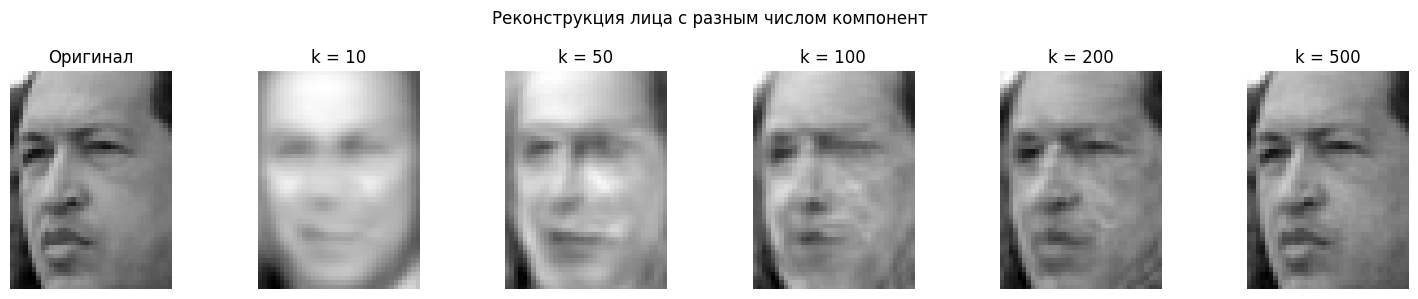

In [8]:
# Реконструируем лицо с разным числом компонент
test_face = X[0]
n_components_list = [10, 50, 100, 200, 500]

fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(15, 3))

# Оригинал
axes[0].imshow(test_face.reshape(h, w), cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

# Реконструкции
for i, n_comp in enumerate(n_components_list):
    reconstructed = reconstruct_face(test_face, mean_face, eigenfaces, n_comp)
    axes[i+1].imshow(reconstructed.reshape(h, w), cmap='gray')
    axes[i+1].set_title(f'k = {n_comp}')
    axes[i+1].axis('off')

plt.suptitle('Реконструкция лица с разным числом компонент')
plt.tight_layout()
plt.show()

### Задание 5 (дополнительное): Вычисление ошибки реконструкции

Вычислите среднеквадратичную ошибку (MSE) реконструкции для разного числа компонент.

In [9]:
# TODO: Вычислите MSE для каждого числа компонент из n_components_list
# MSE = np.mean((original - reconstructed)**2)

print("Ошибка реконструкции (MSE):")
for n_comp in n_components_list:
    reconstructed = reconstruct_face(test_face, mean_face, eigenfaces, n_comp)
    mse = np.mean((test_face - reconstructed)**2)
    print(f"  k = {n_comp}: MSE = {mse:.4f}")

Ошибка реконструкции (MSE):
  k = 10: MSE = 0.0097
  k = 50: MSE = 0.0052
  k = 100: MSE = 0.0022
  k = 200: MSE = 0.0010
  k = 500: MSE = 0.0001


## Итоги

**Eigenfaces** — это классическое применение PCA для распознавания лиц:

1. **Снижение размерности**: Лица живут в подпространстве малой размерности
2. **Извлечение признаков**: Eigenfaces захватывают наиболее важные черты лица
3. **Сжатие**: Лица можно представить небольшим числом коэффициентов

**Ключевое наблюдение**: Первые eigenfaces захватывают глобальные признаки (освещение, форма лица), а последующие — более мелкие детали.